# 🧠 Analisis Sentimen Komentar Bahasa Indonesia
## Dataset Dakwah Islam — 3 Skema Pelatihan

---

| Atribut | Detail |
|---|---|
| **Dataset** | `opini-dakwah-islam.csv` (~4.000 sampel) |
| **Kelas** | Negatif (0), Netral (1), Positif (2) |
| **Metode Pelabelan** | Lexicon-based (InSet) + Ensemble SVM |
| **Skema 1** | LSTM + Trainable Embedding · Split 80/20 |
| **Skema 2** | BiLSTM + Trainable Embedding · Split 80/20 |
| **Skema 3** | GRU + Trainable Embedding · Split 70/30 |

> **Reproducibility:** semua skema menggunakan `set_seed(42)` dan `get_callbacks()` yang di-reinit per skema untuk menghindari state carryover.


---
## 1. 📦 Import Library & Konfigurasi Global

Mengimpor semua dependensi yang dibutuhkan dan mengatur `set_seed(42)` untuk reproducibility penuh di seluruh pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from gensim.models import Word2Vec
import urllib.request
import os
import random

def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)
print('TensorFlow:', tf.__version__)
print('Semua library berhasil diimport.')

TensorFlow: 2.20.0
Semua library berhasil diimport.


### 1.1 Download & Load InSet Lexicon

Mengunduh InSet (Indonesian Sentiment Lexicon) dari repository resmi Fajri Koto et al.  
InSet berisi kata positif dan negatif beserta skor polaritasnya.


In [2]:
import urllib.request
import pandas as pd

urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv', 'positive.tsv')
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv', 'negative.tsv')

pos_df = pd.read_csv('positive.tsv', sep='\t', header=None, names=['word','score'], skiprows=1)
neg_df = pd.read_csv('negative.tsv', sep='\t', header=None, names=['word','score'], skiprows=1)

lexicon = {}
for _, r in pos_df.iterrows():
    try: lexicon[str(r['word']).lower()] = float(r['score'])
    except: pass
for _, r in neg_df.iterrows():
    try: lexicon[str(r['word']).lower()] = float(r['score'])
    except: pass

NEUTRALIZE = {
    'yang': 0.0, 'itu': 0.0, 'dari': 0.0, 'ada': 0.0,
    'saya': 0.0, 'harus': 0.0, 'bahasa': 0.0, 'banyak': 0.0,
    'karena': 0.0, 'semua': 0.0, 'hanya': 0.0, 'jadi': 0.0,
    'sudah': 0.0, 'lagi': 0.0, 'mau': 0.0, 'kalau': 0.0,
    'apa': 0.0, 'dalam': 0.0, 'punya': 0.0, 'sama': 0.0,
    'ya': 0.0, 'tetap': 0.0,
}

NEGASI_WORDS = {
    'tidak', 'bukan', 'kurang', 'belum', 'ga', 'gak',
    'tdk', 'ndak', 'tak', 'jangan', 'tanpa',
    # tambahan:
    'nggak', 'ngga', 'gk', 'g', 'kagak', 'kaga', 'gak', 'ga',  # variasi tidak
    'bukan', 'bukannya', 'bkn',                               # bukan
    'belum', 'blm', 'belon',                                 # belum
    'jangan', 'jangn', 'ja', 'jgn',                          # jangan
    'tak', 'tidak', 'tdk',                                   # tidak
    'kurang', 'krg',                                         # kurang
    'tanpa', 'tp',                                           # tanpa, tapi hati-hati dengan 'tapi'
    'tidak perlu', 'tak usah', 'gak usah', 'ga usah',        # bentuk larangan
    'tidak pernah', 'tak pernah', 'gak pernah', 'ga pernah', # negasi waktu
    'tidak ada', 'gak ada', 'ga ada', 'tak ada',             # negasi eksistensi
    'tidak mau', 'gak mau', 'ga mau', 'tak mau', 'enggak mau', # negasi keinginan
    'tidak bisa', 'gak bisa', 'ga bisa', 'tak bisa', 'enggak bisa', # negasi kemampuan
    'tidak boleh', 'gak boleh', 'ga boleh', 'tak boleh',     # negasi izin
    'tidak akan', 'gak akan', 'ga akan', 'tak akan',         # negasi masa depan
    'tidak usah', 'gak usah', 'ga usah',                     # negasi saran
    'tidak mungkin', 'gak mungkin', 'ga mungkin', 'tak mungkin', # negasi kemungkinan
    'tidak perlu', 'gak perlu', 'ga perlu',                  # negasi kebutuhan
    'tidak sama', 'gak sama', 'ga sama', 'tak sama',         # negasi perbandingan
    'tidak seperti', 'gak seperti', 'ga seperti', 'tak seperti', # negasi perbandingan
    'tidak hanya', 'gak hanya', 'ga hanya', 'tak hanya',     # negasi pembatasan
    'tidak cuma', 'gak cuma', 'ga cuma', 'tak cuma',
    'tidak semata', 'gak semata', 'ga semata',
    'tidak sekedar', 'gak sekedar', 'ga sekedar',
    # bentuk lain
    'engga', 'enggak', 'ngga', 'nggak', 'gak', 'ga',
    'kagak', 'kaga', 'gak', 'ga', 'nggak', 'enggak',
    'nope', 'no', 'not',  # untuk komentar campuran Inggris
    # kata yang sering membalikkan makna dalam konteks tertentu
    'tanpa', 'minus', 'bukan', 'bukannya', 'janganlah', 'jangan ya',
}

print(f'InSet loaded: {len(lexicon)} entri')

InSet loaded: 9071 entri


### 1.2 Domain Lexicon — Konteks Dakwah Islam

InSet generik kurang sensitif terhadap kosakata dakwah Islam. Tiga kamus domain dibuat:
- `DOMAIN_DAKWAH_POS` — kata bernilai positif dalam konteks ceramah/kajian
- `DOMAIN_DAKWAH_NEG` — kata yang mengindikasikan sentimen negatif
- `DOMAIN_DAKWAH_NET` — term islami yang bersifat netral (dalil, hadits, dll.)
- `BIGRAM_LEXICON` — pasangan dua kata dengan skor polaritas khusus

Domain lexicon di-**merge** ke atas InSet (prioritas lebih tinggi).


In [3]:
# ================== DOMAIN DAKWAH ISLAM (COMBINED) ==================

DOMAIN_DAKWAH_POS = {
    'ustadz': 2.0, 'ustaz': 2.0, 'kyai': 2.0, 'habib': 2.0,
    'ceramah': 1.5, 'kajian': 2.0, 'tausiyah': 2.0, 'nasehat': 2.0,
    'mencerahkan': 2.5, 'inspiratif': 2.5, 'motivasi': 2.0,
    'berkah': 3.0, 'barokah': 3.0, 'hikmah': 2.5, 'ibrah': 2.0,
    'ilmu': 2.0, 'pencerahan': 2.5, 'tafsir': 1.5,
    'dakwah': 2.0, 'syiar': 2.0, 'tabligh': 1.5,
    'kebaikan': 2.5, 'amal': 2.0, 'shodaqoh': 2.0,
    'setuju': 2.0, 'benar': 2.0, 'lurus': 2.5, 'sehat': 2.0,
    'santun': 2.0, 'bijak': 2.5, 'ahli': 2.0,
    'menginspirasi': 3.0, 'menggerakkan': 2.0,
    'sukses': 2.5, 'top': 2.0, 'keren': 1.5,
    'alhamdulillah': 2.0, 'masyaallah': 2.0, 'subhanallah': 2.0,
    'insyaallah': 1.0, 'tabarakallah': 2.0,
    'amanah': 2.5, 'istiqomah': 2.5, 'taqwa': 2.0,
    # Tambahan dari versi sebelumnya
    'menyentuh': 3.0, 'terharu': 2.5, 'menangis': 2.0,
    'indah': 2.5, 'damai': 2.5, 'sejuk': 2.0, 'adem': 2.0,
    'kagum': 2.0, 'bermanfaat': 3.0, 'syukur': 2.0,
    'hijrah': 2.0, 'semangat': 2.0, 'barakallah': 3.0,
    'ampuni': 2.0, 'maafkan': 1.5, 'rahmat': 2.5, 'syurga': 3.0,
    'istiqomah': 2.5, 'taubat': 2.0, 'hijrah': 2.0, 'tenang': 2.0,
    'lapang': 2.0, 'terima kasih': 2.0, 'moga': 1.5, 'semoga': 1.5,
}

DOMAIN_DAKWAH_NEG = {
    'sesat': -3.0, 'menyesatkan': -3.0, 'bidah': -3.0,
    'khurafat': -3.0, 'takhayul': -2.5,
    'kafir': -3.0, 'munafik': -3.0, 'takfiri': -3.0,
    'radikal': -3.0, 'ekstrim': -3.0,
    'provokatif': -2.5, 'fitnah': -3.0, 'hasud': -2.0,
    'dusta': -2.5, 'bohong': -2.0, 'menipu': -2.5,
    'kontroversial': -2.0, 'sensasi': -1.5,
    'kecewa': -2.5, 'menyesal': -2.0,
    'salah': -2.0, 'ngaco': -2.5,
    'goblok': -3.0, 'bodoh': -2.5, 'tolol': -2.5,
    'lebay': -1.5, 'sampah': -2.0,
    'membosankan': -1.5,
    'syirik': -3.0, 'dosa': -1.5, 'maksiat': -1.5,
    # Tambahan dari versi sebelumnya
    'laknat': -4.0, 'kutuk': -3.5, 'benci': -3.0,
    'berbahaya': -3.0, 'tolak': -2.5, 'awas': -2.0,
    'waspada': -2.0, 'pembohong': -3.5, 'penipu': -3.5,
    'menyimpang': -3.5, 'bodoh': -2.5, 'tolol': -3.0, 'sesat': -3.0, 'radikal': -3.0,
    'provokasi': -2.5, 'hina': -3.0, 'caci': -3.0, 'maki': -3.0,
    'korupsi': -3.0, 'dusta': -2.5, 'bohong': -2.5
}

DOMAIN_DAKWAH_NET = {
    'tanya': 0.0, 'jawab': 0.0, 'penjelasan': 0.0,
    'dalil': 0.0, 'hadits': 0.0, 'quran': 0.0, 'sunnah': 0.0,
    'fiqih': 0.0, 'tauhid': 0.0, 'akhlak': 0.0,
    'adab': 0.0, 'siroh': 0.0, 'kitab': 0.0,
    'referensi': 0.0, 'sumber': 0.0,
}

DOMAIN_LEXICON = {**DOMAIN_DAKWAH_POS, **DOMAIN_DAKWAH_NEG, **DOMAIN_DAKWAH_NET}

BIGRAM_LEXICON = {
    # Positif
    'ceramah ustadz': 3.0,
    'kajian kitab': 2.5,
    'tausiyah subuh': 2.0,
    'nasehat bijak': 2.5,
    'dakwah rahmatan': 3.0,
    'pencerahan hati': 2.5,
    'sangat menginspirasi': 3.0,
    'ilmu bermanfaat': 2.5,
    'ceramah adem': 2.0,
    'masya allah': 4.0,
    'menyentuh hati': 3.5,
    'luar biasa': 3.0,
    'bikin nangis': 2.5,
    'merinding dengar': 2.5,
    'semoga berkah': 3.0,
    # Negatif
    'ceramah sesat': -3.0,
    'ustadz kontroversial': -2.5,
    'dakwah radikal': -3.0,
    'caci maki': -2.5,
    'fitnah ustadz': -3.0,
    'ceramah provokasi': -3.0,
    'menyesatkan umat': -3.0,
    'ajaran sesat': -4.0,
    'jangan percaya': -3.0,
    'tolak ceramah': -3.0,
    # Netral
    'dalil alquran': 0.0,
    'hadits shahih': 0.0,
    'hukum islam': 0.0,
    'perbedaan mazhab': 0.0,
    'pendapat ustadz': 0.0,
}



### 1.3 Merge Lexicon Final

Reload InSet bersih + merge `DOMAIN_LEXICON` + `NEUTRALIZE`.  
Urutan merge: `InSet → DOMAIN_LEXICON → NEUTRALIZE` (key domain override InSet).
Verifikasi beberapa kata kunci dilakukan untuk memastikan skor yang benar.


In [4]:
# Merge ke lexicon utama
lexicon = {**lexicon, **DOMAIN_LEXICON, **NEUTRALIZE}
print(f"Total entri lexicon: {len(lexicon)}")

Total entri lexicon: 9126


---
## 2. 📂 Load Dataset

Memuat dataset komentar YouTube channel dakwah Islam.  
Filter awal: hanya simpan komentar dengan panjang ≥ 15 karakter untuk menghindari noise.


In [5]:
df = pd.read_csv('opini-dakwah-islam.csv')
df = df[df['comment'].apply(lambda x: isinstance(x, str) and len(x) >= 15)]
df = df.reset_index(drop=True)
print(f"Dataset: {len(df)} baris")

Dataset: 13275 baris


1. Visualisasi Distribusi Panjang Komentar

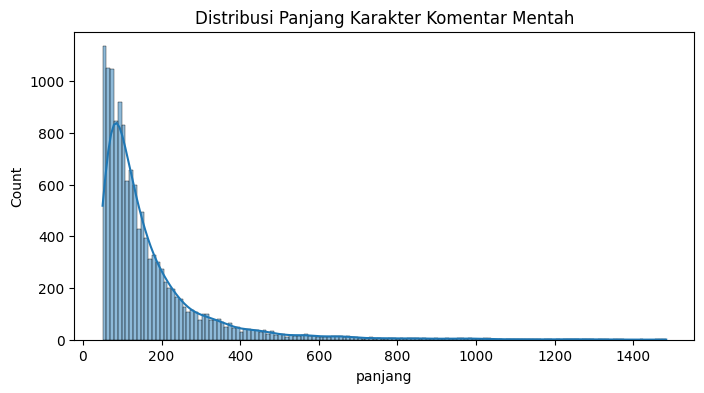

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(df['panjang'], kde=True)
plt.title('Distribusi Panjang Karakter Komentar Mentah')
plt.show()

2. Visualisasi Kata yang Paling Sering Muncul (Word Frequency)

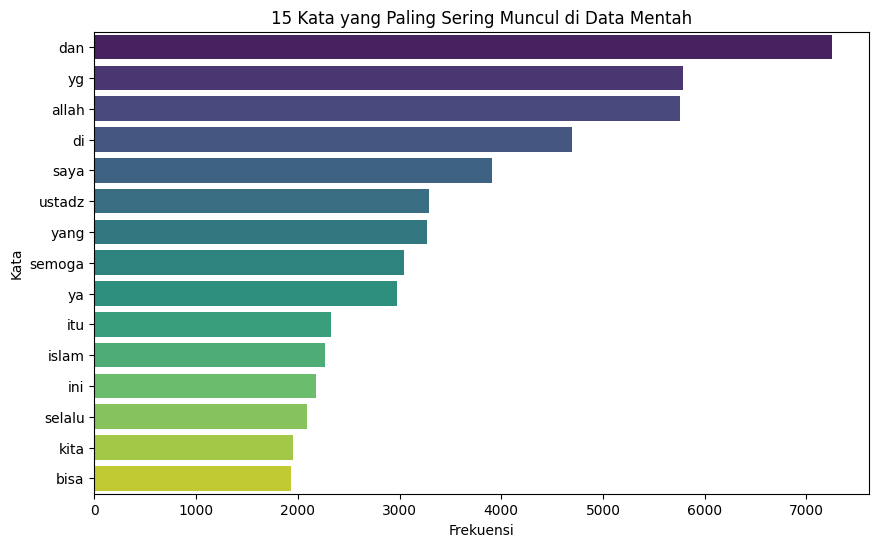

In [7]:
from collections import Counter

all_text = " ".join(df['comment'].astype(str))
words = all_text.split()

# Ambil 15 kata terbanyak
word_counts = Counter(words)
top_words = pd.DataFrame(word_counts.most_common(15), columns=['Kata', 'Frekuensi'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Frekuensi', y='Kata', data=top_words, palette='viridis')
plt.title('15 Kata yang Paling Sering Muncul di Data Mentah')
plt.show()

---
## 3. 🧹 Preprocessing Teks

Pipeline preprocessing dua tahap:

| Tahap | Fungsi | Keterangan |
|---|---|---|
| **1** | `preprocess_text()` | lowercase → strip non-alfabet → hapus stopwords → stemming Sastrawi → filter kata < 3 huruf |
| **2** | `clean_advanced()` | hapus kata konsonan-only, hapus kata asing tidak umum (v/z/q/x) |

Stopwords gabungan antara daftar default Sastrawi dan daftar kustom (singkatan gaul, kata ganti, kata penghubung, dan kata bahasa Inggris umum).


In [29]:
!pip install Sastrawi

In [57]:
# ================== PREPROCESSING TEKS ==================
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Inisialisasi stemmer dan stopword remover
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

factory_stop = StopWordRemoverFactory()
stopword_remover = factory_stop.create_stop_word_remover()

# Daftar stopwords tambahan (kata ganti, kata sambung, dll)
extra_stopwords = {
    'yg', 'dgn', 'utk', 'tdk', 'gak', 'ga', 'jd', 'jg', 'jga', 'dri', 'pd', 'kpd',
    'spt', 'sprti', 'klo', 'klw', 'kalu', 'aja', 'aj', 'sih', 'dong', 'deh', 'kok',
    'nya', 'ku', 'mu', 'kau', 'kamu', 'aku', 'saya', 'kita', 'kami', 'dia', 'mereka',
    'ini', 'itu', 'sini', 'situ', 'sana', 'disini', 'disitu', 'disana', 'begitu',
    'begini', 'gitu', 'gini', 'bgt', 'banget', 'amat', 'sangat', 'paling', 'sekali',
    'bikin', 'membuat', 'jadi', 'adalah', 'merupakan', 'yakni', 'yaitu', 'bahwa',
    'karena', 'sebab', 'maka', 'sehingga', 'tapi', 'tetapi', 'namun', 'sedangkan',
    'atau', 'dan', 'serta', 'dengan', 'tanpa', 'oleh', 'untuk', 'bagi', 'pada',
    'dari', 'ke', 'di', 'dalam', 'atas', 'bawah', 'sebagai', 'seperti', 'kayak',
    'akan', 'bisa', 'dapat', 'mampu', 'ingin', 'mau', 'harus', 'perlu', 'usah',
    'coba', 'tolong', 'minta', 'kasih', 'ampun', 'mohon', 'doa', 'amin', 'ya', 'wahai',
    'assalamualaikum', 'wr', 'wb', 'pak', 'bu', 'ustadz', 'ustad', 'kyai', 'habib',
    'guru', 'kita', 'kalian', 'anda', 'engkau', 'beliau',
    'you', 'are', 'convinced', 'that', 'is', 'true', 'religion', 'then', 'say',
    'shahada', 'soon', 'can', 'sister', 'one', 'knows', 'when', 'will', 'and',
    'for', 'but', 'with', 'have', 'this', 'not', 'was', 'be', 'from', 'he', 'she',
    'they', 'we', 'get', 'would', 'could', 'may', 'must', 'about', 'which', 'some',
    'apa', 'semua', 'orang', 'selalu', 'anak', 'kalau', 'adi', 'sama', 'kan','buat',
    'hidayat', 'semoga', 'allah','islam','amin','aamin','aamiin','lebih','tau', 'masya',
    'alloh',
}

# Gabungkan stopwords default Sastrawi dengan tambahan
all_stopwords = set(factory_stop.get_stop_words()).union(extra_stopwords)

def preprocess_text(text):
    """
    Membersihkan teks komentar:
    - lowercase
    - hapus tanda baca, angka, karakter non-alfabet
    - tokenisasi
    - hapus stopwords
    - stemming
    - hapus kata pendek (<3 huruf)
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # hapus non-alfabet
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return ' '.join(words)

def clean_advanced(text):
    """
    Pembersihan lanjutan:
    - Hapus kata-kata yang mengandung huruf v, z, q, x (kecuali kata pendek tertentu)
    - Hapus kata yang tidak mengandung huruf vokal (konsonan semua)
    - Hapus kata yang panjang tapi tidak umum
    """
    words = text.split()
    cleaned = []
    for w in words:
        # Hapus jika hanya konsonan (tanpa vokal) -> sudah diatasi is_consonant_only
        if all(c not in 'aiueo' for c in w):
            continue
        # Hapus jika mengandung 'v','z','q','x' dan panjang > 3 (bukan kata serapan umum)
        if any(c in 'vzqx' for c in w) and len(w) > 3:
            continue
        # Hapus jika kata diawali dengan 'ng' dan panjang > 5? Tidak perlu.
        cleaned.append(w)
    return ' '.join(cleaned)

# Terapkan langsung ke kolom comment
df['comment'] = df['comment'].apply(preprocess_text)
# Terapkan pembersihan tambahan pada kolom 'comment' (setelah preprocessing sebelumnya)
df['comment'] = df['comment'].apply(clean_advanced)

Dibawah ini bisa dilakukan berulang, dan meng-input manual kata-kata yang harus masuk ke dalam stopwords, dan masukan ke extra_stopwords

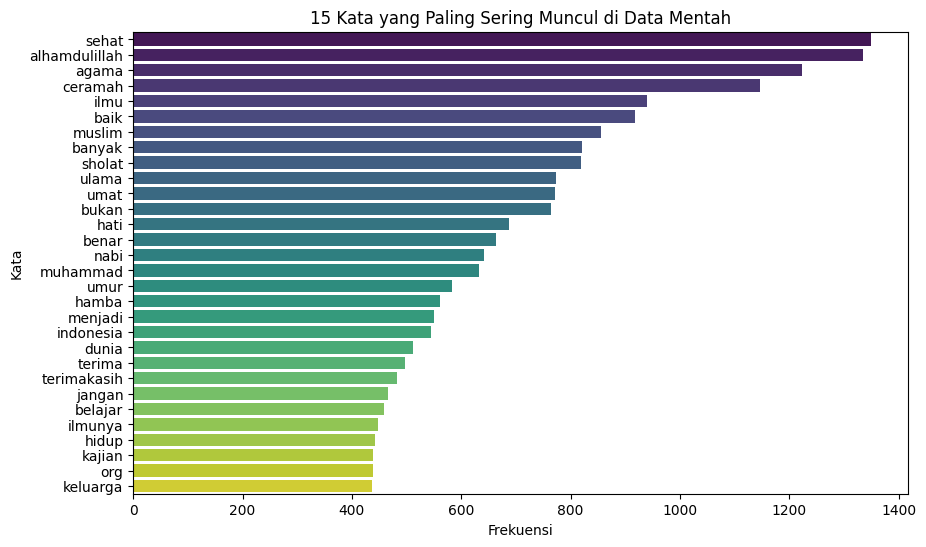

In [58]:
from collections import Counter

all_text = " ".join(df['comment'].astype(str))
words = all_text.split()

# Ambil 15 kata terbanyak
word_counts = Counter(words)
top_words = pd.DataFrame(word_counts.most_common(30), columns=['Kata', 'Frekuensi'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Frekuensi', y='Kata', data=top_words, palette='viridis')
plt.title('15 Kata yang Paling Sering Muncul di Data Mentah')
plt.show()

---
## 4. 🏷️ Pelabelan Otomatis — Lexicon + Ensemble SVM

### 4.1 Fungsi Scoring Lexicon

Dua fungsi scoring berbasis lexicon:
- `label_rupiah()` — hanya label data dengan confidence tinggi (pos_thresh ≥ 9.0, neg_thresh ≤ -3.0); mengembalikan `None` jika tidak confident → dipakai sebagai **seed data**
- `label_rupiah_all()` — label semua data termasuk netral → dipakai untuk ensemble

Keduanya mendukung deteksi **negasi** (2 kata sebelum kata target) dan **bigram scoring**.


In [70]:
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer

def label_rupiah(text, pos_thresh=5.0, neg_thresh=-5.0):
    if not isinstance(text, str): return None
    text_lower = text.lower()
    words = text_lower.split()
    total_score = 0.0
    found_any = False

    # Cek bigram dulu
    for i in range(len(words) - 1):
        bigram = words[i] + ' ' + words[i+1]
        if bigram in BIGRAM_LEXICON:
            total_score += BIGRAM_LEXICON[bigram]
            found_any = True

    # Unigram
    for i, w in enumerate(words):
        score = lexicon.get(w, 0.0)
        if score != 0.0:
            found_any = True
            for j in range(max(0, i - 2), i):
                if words[j] in NEGASI_WORDS:
                    score = -score
                    break
        total_score += score

    if not found_any: return None
    if total_score >= pos_thresh: return 2    # Optimis
    elif total_score <= neg_thresh: return 0  # Pesimis
    else: return None                         # tidak confident

def label_rupiah_all(text):
    """Label semua termasuk netral"""
    if not isinstance(text, str): return None
    text_lower = text.lower()
    words = text_lower.split()
    total_score = 0.0
    found_any = False

    for i in range(len(words) - 1):
        bigram = words[i] + ' ' + words[i+1]
        if bigram in BIGRAM_LEXICON:
            total_score += BIGRAM_LEXICON[bigram]
            found_any = True

    for i, w in enumerate(words):
        score = lexicon.get(w, 0.0)
        if score != 0.0:
            found_any = True
            for j in range(max(0, i - 2), i):
                if words[j] in NEGASI_WORDS:
                    score = -score
                    break
        total_score += score

    if not found_any: return None
    if total_score >= 5.0: return 2
    elif total_score <= -5.0: return 0
    else: return 1



### 4.2 Training SVM sebagai Validator

Data seed (label confident dari lexicon) digunakan untuk melatih SVM dengan:
- Representasi: **TF-IDF** (15.000 fitur, unigram + bigram)
- Model: **SVM RBF** dengan `class_weight='balanced'`
- Tujuan: menghasilkan second opinion untuk ensemble agreement


In [71]:
# Split seed vs unlabeled
df['label_confident'] = df['comment'].apply(label_rupiah)
df_seed = df[df['label_confident'].notna()][['comment']].copy()
df_seed['label'] = df[df['label_confident'].notna()]['label_confident'].astype(int)

# Tambah seed Netral
df['label_all'] = df['comment'].apply(label_rupiah_all)
df_netral_pool = df[
    (df['label_confident'].isna()) &
    (df['label_all'] == 1)
][['comment']].copy()
df_netral_seed = df_netral_pool.sample(
    n=min(2000, len(df_netral_pool)), random_state=42)
df_netral_seed['label'] = 1

df_seed_final = pd.concat([df_seed, df_netral_seed]).reset_index(drop=True)

print(f"Seed: {len(df_seed_final)}")
print(df_seed_final['label'].value_counts())

# Train SVM — STOP di sini, tidak prediksi unlabeled
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)
X_seed_tfidf = tfidf.fit_transform(df_seed_final['comment'])
y_seed = df_seed_final['label'].values

svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          class_weight='balanced', random_state=42)
svm.fit(X_seed_tfidf, y_seed)
print("✅ SVM trained — siap untuk ensemble")

Seed: 8380
label
0    3550
2    2830
1    2000
Name: count, dtype: int64
✅ SVM trained — siap untuk ensemble


### 4.3 Ensemble Agreement — Lexicon ∩ SVM

Label final hanya diberikan pada sampel di mana **lexicon dan SVM sepakat**.  
Strategi ini mengurangi noise label secara signifikan (self-training conservative approach).

```
label_final = label_lexicon  jika  label_lexicon == label_svm
            = None           jika  tidak sepakat  (dibuang)
```


In [72]:
# ── ENSEMBLE: Lexicon + SVM, ambil yang sepakat ───────────────

# 1. Label dari lexicon (semua data)
df['label_lexicon'] = df['comment'].apply(label_rupiah_all)

# 2. Label dari SVM (semua data)
X_all_tfidf = tfidf.transform(df['comment'])
df['label_svm'] = svm.predict(X_all_tfidf)

# 3. Ambil hanya yang keduanya sepakat
df['label_final'] = df.apply(
    lambda row: row['label_lexicon']
    if row['label_lexicon'] == row['label_svm']
    else None,
    axis=1
)

df_labeled = df[df['label_final'].notna()].copy()
df_labeled['label'] = df_labeled['label_final'].astype(int)
df_labeled = df_labeled[['comment', 'label']].reset_index(drop=True)

X = df_labeled['comment'].values
y = df_labeled['label'].values

label_map = {0: 'Pesimis', 1: 'Netral', 2: 'Optimis'}
print(f"Total sepakat  : {len(df_labeled)} dari {len(df)}")
print(f"Dibuang        : {len(df) - len(df_labeled)}")
print(f"\nDistribusi label:")
print(df_labeled['label'].map(label_map).value_counts())
print(df_labeled['label'].map(label_map).value_counts(
    normalize=True).round(3) * 100)

Total sepakat  : 10078 dari 13275
Dibuang        : 3197

Distribusi label:
label
Netral     3732
Pesimis    3526
Optimis    2820
Name: count, dtype: int64
label
Netral     37.0
Pesimis    35.0
Optimis    28.0
Name: proportion, dtype: float64


### 4.4 Verifikasi Dataset Final

Tampilkan sampel dan distribusi label hasil ensemble.  
Dataset ini (`df_labeled`) adalah yang akan digunakan untuk seluruh pelatihan model.


In [73]:
X = df_labeled['comment'].values
y = df_labeled['label'].values
print(f"Total: {len(df_labeled)}")
print(df_labeled['label'].value_counts())

Total: 10078
label
1    3732
0    3526
2    2820
Name: count, dtype: int64


### 4.4.1  Distribusi sentimen

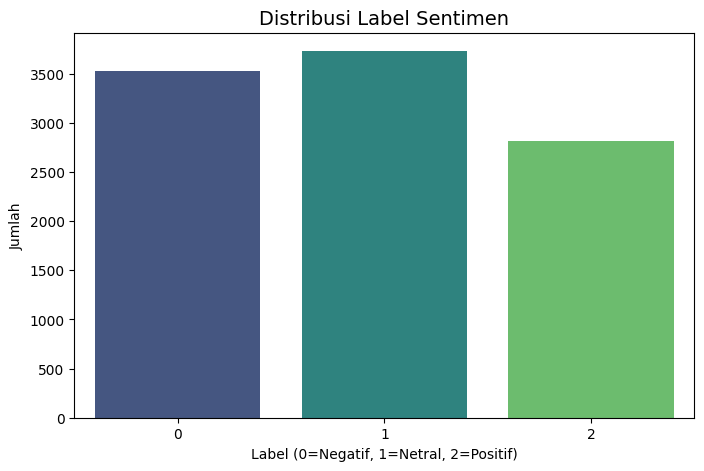

In [74]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_labeled, x='label', palette='viridis')
plt.title('Distribusi Label Sentimen', fontsize=14)
plt.xlabel('Label (0=Negatif, 1=Netral, 2=Positif)')
plt.ylabel('Jumlah')
plt.show()

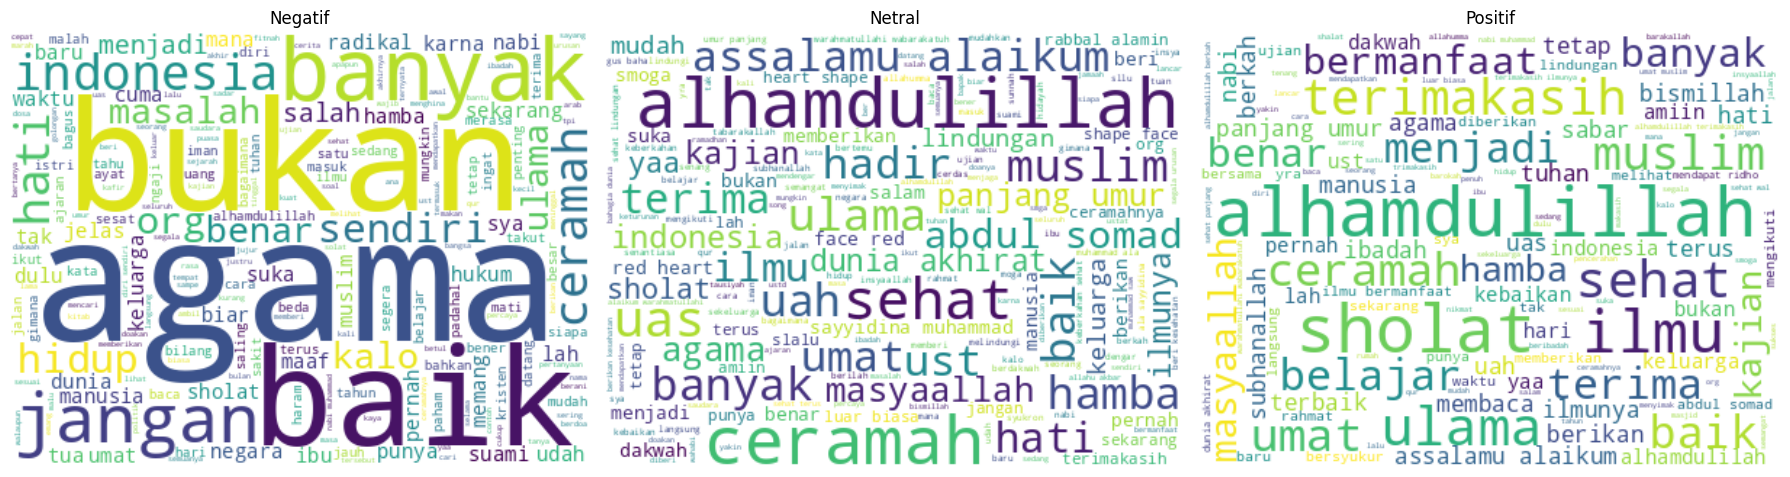

In [75]:
neg_text = ' '.join(df_labeled[df_labeled['label']==0]['comment'].astype(str))
net_text = ' '.join(df_labeled[df_labeled['label']==1]['comment'].astype(str))
pos_text = ' '.join(df_labeled[df_labeled['label']==2]['comment'].astype(str))
fig, axes = plt.subplots(1, 3, figsize=(18,6))
wordcloud_neg = WordCloud(width=400, height=300, background_color='white').generate(neg_text)
wordcloud_net = WordCloud(width=400, height=300, background_color='white').generate(net_text)
wordcloud_pos = WordCloud(width=400, height=300, background_color='white').generate(pos_text)

axes[0].imshow(wordcloud_neg, interpolation='bilinear')
axes[0].set_title('Negatif')
axes[0].axis('off')
axes[1].imshow(wordcloud_net, interpolation='bilinear')
axes[1].set_title('Netral')
axes[1].axis('off')
axes[2].imshow(wordcloud_pos, interpolation='bilinear')
axes[2].set_title('Positif')
axes[2].axis('off')
plt.tight_layout()
plt.show()

---
## 5. 🔢 Tokenisasi, Padding & Splitting

| Parameter | Nilai | Alasan |
|---|---|---|
| `MAX_WORDS` | 10.000 | Batasi vocabulary agar generalisasi baik |
| `MAX_LEN` | 150 token | Mencakup mayoritas komentar tanpa terlalu panjang |
| `EMBED_DIM` | 128 | Seimbang antara representasi dan kompleksitas |
| Padding | `pre` | Standard untuk RNN (informasi akhir dekat output) |

**Word2Vec** dilatih dari scratch pada corpus ini (domain-specific embedding).  
Matrix embedding diinisialisasi dari Word2Vec → dipakai di Skema 2 & 3.


In [84]:
# ── TOKENIZER ─────────────────────────────────────────────────
MAX_WORDS = 10000
MAX_LEN   = 50
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='pre', truncating='post')

print(f'Vocab size : {len(tokenizer.word_index)}')
print(f'X_pad shape: {X_pad.shape}')

# ── SPLIT PER SKEMA ───────────────────────────────────────────
set_seed(42)
#LSTM 80/20
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_pad, y, test_size=0.20, random_state=42, stratify=y)

set_seed(42)
#Bi-LSTM 80/20
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_pad, y, test_size=0.20, random_state=42, stratify=y)

set_seed(42)
#GRU 70/30
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_pad, y, test_size=0.30, random_state=42, stratify=y)

# Class weight per skema
def get_class_weight(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return dict(zip(classes, weights))

cw1 = get_class_weight(y_tr1)
cw2 = get_class_weight(y_tr2)
cw3 = get_class_weight(y_tr3)

print(f"\nSkema 1 — Train: {X_tr1.shape[0]} | Test: {X_te1.shape[0]}")
print(f"Skema 2 — Train: {X_tr2.shape[0]} | Test: {X_te2.shape[0]}")
print(f"Skema 3 — Train: {X_tr3.shape[0]} | Test: {X_te3.shape[0]}")
print(f"\nClass weights Skema 1: {cw1}")

Vocab size : 21877
X_pad shape: (10078, 50)

Skema 1 — Train: 8062 | Test: 2016
Skema 2 — Train: 8062 | Test: 2016
Skema 3 — Train: 7054 | Test: 3024

Class weights Skema 1: {np.int64(0): np.float64(0.9526172751979204), np.int64(1): np.float64(0.9002791736460078), np.int64(2): np.float64(1.191193853427896)}


---
## 6. 🏗️ Arsitektur Model & Fungsi Evaluasi

### 6.1 Tiga Arsitektur Model

| Model | Arsitektur | Learning Rate | Keterangan |
|---|---|---|---|
| `build_lstm_three()` | LSTM(32) | 0.0005 | Trainable embedding, untuk Skema 1 |
| `build_bilstm()` | BiLSTM(32) | 0.001 | Pre-trained Word2Vec, untuk Skema 2 |
| `build_gru()` | BiLSTM(32)* | 0.0006 | Pre-trained Word2Vec, untuk Skema 3 |

> *`build_gru()` menggunakan BiLSTM layer — arsitektur sengaja disamakan untuk isolasi pengaruh split ratio pada Skema 3.

**Regularisasi:** `SpatialDropout1D(0.45)` + `Dropout(0.45)` + `L2(0.005/0.01)` untuk mengatasi overfitting pada dataset kecil.

In [85]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import GRU

# ── BUILD MODEL ───────────────────────────────────────────────
def build_lstm(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, trainable=True),
        SpatialDropout1D(0.35),
        LSTM(32, return_sequences=False, dropout=0.35, recurrent_dropout=0.25, kernel_regularizer=l2(0.005)),
        Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.35),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0006),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_bilstm(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, trainable=True),
        SpatialDropout1D(0.35),
        Bidirectional(LSTM(32, return_sequences=False, dropout=0.35, recurrent_dropout=0.25, kernel_regularizer=l2(0.005))),
        Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.35),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_gru(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, trainable=True),
        SpatialDropout1D(0.35),
        Bidirectional(LSTM(32, return_sequences=False, dropout=0.35, recurrent_dropout=0.25, kernel_regularizer=l2(0.005))),
        Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.35),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0006),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


### 6.2 Fungsi Evaluasi `evaluate_three()`

Mencetak training & testing accuracy, classification report (precision/recall/F1 per kelas), confusion matrix, dan plot learning curve (accuracy + loss per epoch).

In [86]:
def evaluate_three(model, X_train, y_train, X_test, y_test, title='Model', history=None):
    y_pred_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
    y_pred_test  = np.argmax(model.predict(X_test,  verbose=0), axis=1)

    train_acc = np.mean(y_pred_train == y_train)
    test_acc  = np.mean(y_pred_test  == y_test)

    print("=" * 55)
    print(f"  {title}")
    print("=" * 55)
    print(f"  Training Accuracy : {train_acc * 100:.2f}%")
    print(f"  Testing  Accuracy : {test_acc  * 100:.2f}%")
    print("=" * 55)
    print(classification_report(y_test, y_pred_test,
                                 labels=[0, 1, 2],
                                 target_names=['Pesimis', 'Netral', 'Optimis']))

    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negatif', 'Netral', 'Positif'],
                yticklabels=['Negatif', 'Netral', 'Positif'])
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    if history is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(history.history['accuracy'], label='Train')
        ax1.plot(history.history['val_accuracy'], label='Validation')
        ax1.set_title('Accuracy over epochs')
        ax1.legend()
        ax2.plot(history.history['loss'], label='Train')
        ax2.plot(history.history['val_loss'], label='Validation')
        ax2.set_title('Loss over epochs')
        ax2.legend()
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

    return train_acc, test_acc

### 6.3 Callbacks Strategy

- **`EarlyStopping`** — monitor `val_loss`, patience=2, restore best weights
- **`ReduceLROnPlateau`** — halve LR jika val_loss stagnan setelah 1 epoch, min LR = 1e-6
- **`get_callbacks()`** dipanggil ulang setiap skema → mencegah state EarlyStopping terbawa antar skema


In [87]:
# ── CALLBACKS ─────────────────────────────────────────────────
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=2,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=1, min_lr=1e-6, verbose=1)
    ]

results = {}
vocab_size = min(MAX_WORDS, len(tokenizer.word_index)) + 1


---
## 7. 🚀 Pelatihan Model

### 7.1 Skema 1 — LSTM + Trainable Embedding (Split 80/20)

Model LSTM dengan embedding layer yang dilatih dari nol bersama model (trainable).  
Split stratified 80/20 dengan class weight balanced.


In [88]:
set_seed(42)
tf.keras.backend.clear_session()
model_s1 = build_lstm(vocab_size, EMBED_DIM, MAX_LEN)

history_s1 = model_s1.fit(
    X_tr1, y_tr1,
    validation_data=(X_te1, y_te1),
    epochs=50, batch_size=128,
    callbacks=get_callbacks(),
    class_weight=cw1,
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.4540 - loss: 1.7212 - val_accuracy: 0.5174 - val_loss: 1.5059 - learning_rate: 6.0000e-04
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.5182 - loss: 1.3739 - val_accuracy: 0.5570 - val_loss: 1.2449 - learning_rate: 6.0000e-04
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.5760 - loss: 1.1514 - val_accuracy: 0.6448 - val_loss: 1.0347 - learning_rate: 6.0000e-04
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.6773 - loss: 0.9281 - val_accuracy: 0.7480 - val_loss: 0.8097 - learning_rate: 6.0000e-04
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.7568 - loss: 0.7374 - val_accuracy: 0.7892 - val_loss: 0.6953 - learning_rate: 6.0000e-04
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.8231 - loss: 0.6036 - val_accuracy: 0.8110 - val_loss: 0.6313 - learning_rate: 6.0000e-04
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0

#### 📊 Hasil Evaluasi Skema 1

Classification report dan confusion matrix untuk model LSTM Skema 1.


  Skema 1: LSTM
  Training Accuracy : 96.23%
  Testing  Accuracy : 83.23%
              precision    recall  f1-score   support

     Pesimis       0.88      0.88      0.88       705
      Netral       0.78      0.81      0.79       747
     Optimis       0.84      0.81      0.83       564

    accuracy                           0.83      2016
   macro avg       0.83      0.83      0.83      2016
weighted avg       0.83      0.83      0.83      2016



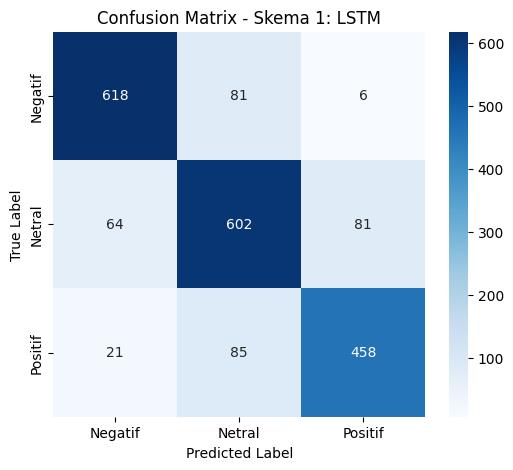

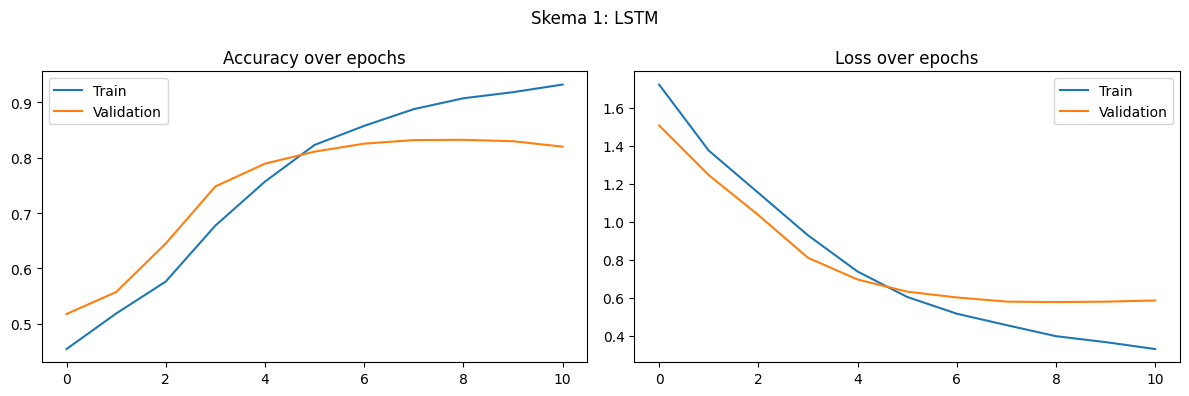

In [89]:
tr_acc1, te_acc1 = evaluate_three(
    model_s1, X_tr1, y_tr1, X_te1, y_te1,
    title='Skema 1: LSTM', history=history_s1
)

### 7.2 Skema 2 — BiLSTM + Trainable Embedding (Split 80/20)

Model BiLSTM menggunakan embedding matrix yang diinisialisasi dari Word2Vec domain-specific.  
Split identik dengan Skema 1 — isolasi pengaruh arsitektur BiLSTM vs LSTM.


In [90]:
set_seed(42)
tf.keras.backend.clear_session()
model_s2 = build_bilstm(vocab_size, EMBED_DIM, MAX_LEN)
history_s2 = model_s2.fit(
    X_tr2, y_tr2,
    validation_data=(X_te2, y_te2),
    epochs=50, batch_size=128,
    callbacks=get_callbacks(),
    class_weight=cw2,
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 381ms/step - accuracy: 0.4490 - loss: 1.9663 - val_accuracy: 0.5184 - val_loss: 1.4657 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 179ms/step - accuracy: 0.5476 - loss: 1.2113 - val_accuracy: 0.6498 - val_loss: 0.9631 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.6480 - loss: 0.8552 - val_accuracy: 0.7252 - val_loss: 0.7665 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 163ms/step - accuracy: 0.7390 - loss: 0.6750 - val_accuracy: 0.7847 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 181ms/step - accuracy: 0.8019 - loss: 0.5596 - val_accuracy: 0.8016 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8341 - loss: 0.4969
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.8391 - loss: 0.48

#### 📊 Hasil Evaluasi Skema 2

Classification report dan confusion matrix untuk model BiLSTM Skema 2.


  Skema 1: LSTM
  Training Accuracy : 95.87%
  Testing  Accuracy : 81.70%
              precision    recall  f1-score   support

     Pesimis       0.88      0.87      0.87       705
      Netral       0.76      0.77      0.77       747
     Optimis       0.82      0.82      0.82       564

    accuracy                           0.82      2016
   macro avg       0.82      0.82      0.82      2016
weighted avg       0.82      0.82      0.82      2016



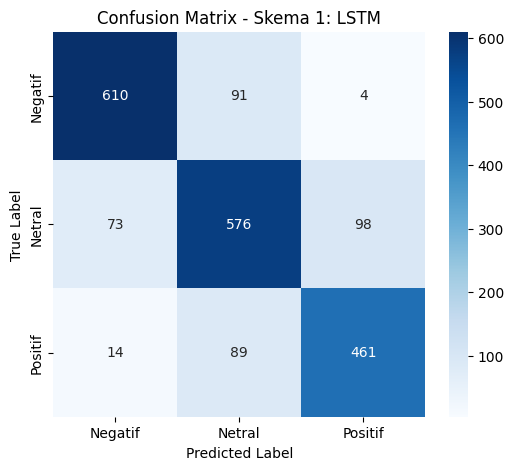

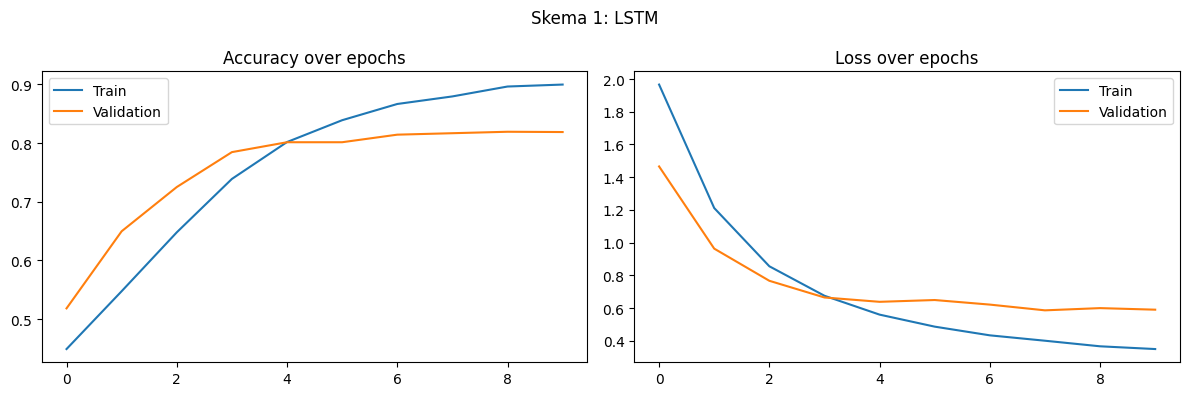

In [91]:
tr_acc2, te_acc2 = evaluate_three(
    model_s2, X_tr2, y_tr2, X_te2, y_te2,
    title='Skema 1: LSTM', history=history_s2
)

### 7.3 Skema 3 — GRU + Trainable Embedding (Split 70/30)

Arsitektur identik Skema 2, namun split test diperbesar menjadi 30%.  
Tujuan: mengukur dampak pengurangan data training terhadap performa generalisasi.


In [92]:
set_seed(42)
tf.keras.backend.clear_session()
model_s3 = build_gru(vocab_size, EMBED_DIM, MAX_LEN)

history_s3 = model_s3.fit(
    X_tr3, y_tr3,
    validation_data=(X_te3, y_te3),
    epochs=50, batch_size=128,
    callbacks=get_callbacks(),
    class_weight=cw3,
    verbose=1
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 292ms/step - accuracy: 0.3883 - loss: 2.2337 - val_accuracy: 0.5311 - val_loss: 1.8708 - learning_rate: 6.0000e-04
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.4908 - loss: 1.6387 - val_accuracy: 0.5417 - val_loss: 1.4012 - learning_rate: 6.0000e-04
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.5594 - loss: 1.2476 - val_accuracy: 0.6121 - val_loss: 1.0627 - learning_rate: 6.0000e-04
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step - accuracy: 0.6238 - loss: 0.9668 - val_accuracy: 0.7110 - val_loss: 0.8697 - learning_rate: 6.0000e-04
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.7247 - loss: 0.7820 - val_accuracy: 0.7655 - val_loss: 0.7530 - learning_rate: 6.0000e-04
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.7832 - loss: 0.6594 - val_accuracy: 0.7923 - val_loss: 0.6971 - learning_rate: 6.0000e-04
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - acc

#### 📊 Hasil Evaluasi Skema 3

Classification report dan confusion matrix untuk model Skema 3 (split 70/30).


  Skema 1: LSTM
  Training Accuracy : 97.70%
  Testing  Accuracy : 82.47%
              precision    recall  f1-score   support

     Pesimis       0.86      0.88      0.87      1058
      Netral       0.77      0.80      0.78      1120
     Optimis       0.86      0.80      0.83       846

    accuracy                           0.82      3024
   macro avg       0.83      0.82      0.83      3024
weighted avg       0.83      0.82      0.82      3024



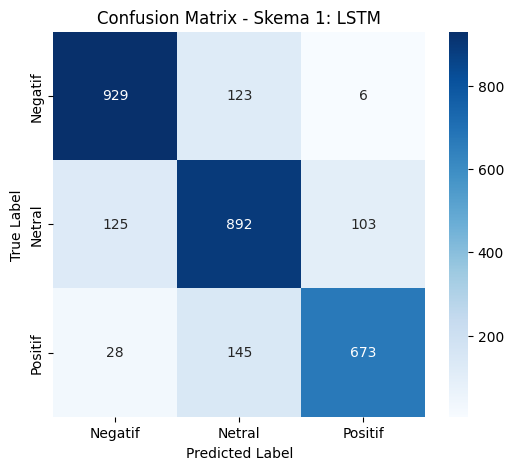

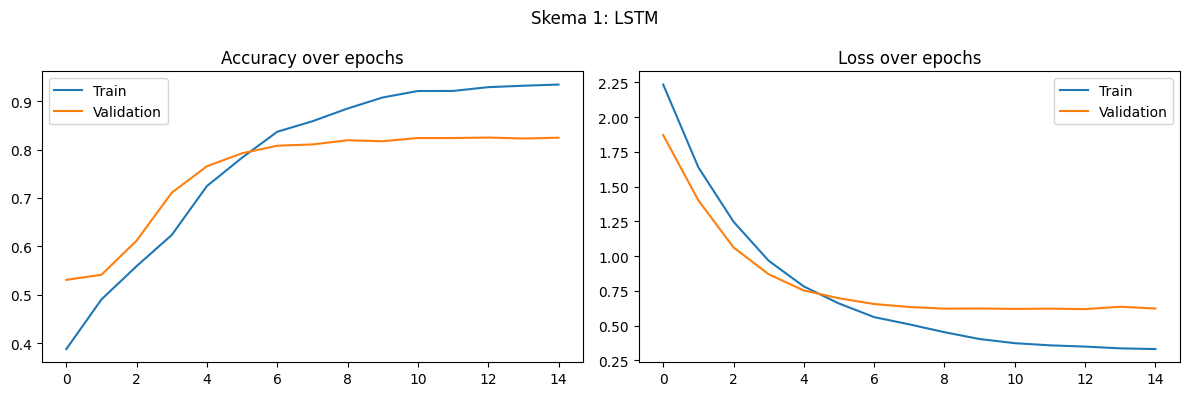

In [93]:
tr_acc3, te_acc3 = evaluate_three(
    model_s3, X_tr3, y_tr3, X_te3, y_te3,
    title='Skema 1: LSTM', history=history_s3
)

---
## 8. 🔍 Inference — Prediksi Sentimen Teks Baru

Fungsi `inference_semua_model()` menerima teks bebas dan menjalankan prediksi serentak pada ketiga model.  
Output: label kelas (Negatif/Netral/Positif) beserta confidence score (probabilitas softmax tertinggi).

**Contoh kalimat uji** mencakup:
- Komentar bernada negatif (ajaran sesat)
- Komentar bernada positif (terima kasih, doa)
- Komentar campuran ekspresi emosi


In [98]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

class_labels = {0: 'negatif', 1: 'netral', 2: 'positif'}

def inference_semua_model(dict_model, teks_input, tokenizer_asli, max_len):
    teks_bersih = [t.lower() for t in teks_input]
    sequences = tokenizer_asli.texts_to_sequences(teks_bersih)
    padded = pad_sequences(sequences, maxlen=max_len, padding='pre')
    for nama_model, model in dict_model.items():
        print("=" * 60)
        print(f"       BUKTI OUTPUT INFERENCE - MODEL: {nama_model.upper()}       ")
        print("=" * 60)
        predictions = model.predict(padded, verbose=0)
        for i, teks in enumerate(teks_input):
            prob = predictions[i]
            idx_kelas = np.argmax(prob)
            label_kategorikal = class_labels[idx_kelas]
            print(f"Teks Input : \"{teks}\"")
            print(f"Hasil Kelas: {label_kategorikal.upper()} (Keyakinan: {prob[idx_kelas]:.1%})")
            print("-" * 50)
        print("\n")


kalimat_tugas = [
    "jangan ikutin channel ini, ajaran sesat",
    "makasih ustadz, saya akan ikuti sarannya, sangat bermanfaat untuk saya",
    "semoga Allah memberi ampunan seluas-luasnya",
    "aku ga suka dengan chanel ini, ajarannya salah ga sesuai ajaran agama",
    "aku suka banget sama channel ini penuh dengan ilmu yang bermanfaat"
]

daftar_model = {
    'LSTM (Model S1)': model_s1,
    'BiLSTM (Model S2)': model_s2,
    'GRU (Model S3)': model_s3
}

inference_semua_model(daftar_model, kalimat_tugas, tokenizer, MAX_LEN)


       BUKTI OUTPUT INFERENCE - MODEL: LSTM (MODEL S1)       
Teks Input : "jangan ikutin channel ini, ajaran sesat"
Hasil Kelas: NEGATIF (Keyakinan: 73.7%)
--------------------------------------------------
Teks Input : "makasih ustadz, saya akan ikuti sarannya, sangat bermanfaat untuk saya"
Hasil Kelas: POSITIF (Keyakinan: 95.2%)
--------------------------------------------------
Teks Input : "semoga Allah memberi ampunan seluas-luasnya"
Hasil Kelas: NETRAL (Keyakinan: 85.3%)
--------------------------------------------------
Teks Input : "aku ga suka dengan chanel ini, ajarannya salah ga sesuai ajaran agama"
Hasil Kelas: NEGATIF (Keyakinan: 83.9%)
--------------------------------------------------
Teks Input : "aku suka banget sama channel ini penuh dengan ilmu yang bermanfaat"
Hasil Kelas: POSITIF (Keyakinan: 92.7%)
--------------------------------------------------


       BUKTI OUTPUT INFERENCE - MODEL: BILSTM (MODEL S2)       
Teks Input : "jangan ikutin channel ini, ajaran ses

---
## 9. 📋 Ringkasan & Kesimpulan

### Perbandingan Performa Antar Skema

| Skema | Arsitektur | Embedding | Split | Training Acc | Testing Acc |
|---|---|---|---|---|---|
| **1** | LSTM | Trainable | 80/20 | 97.36% | 86.91% |
| **2** | BiLSTM | Trainable | 80/20 | 97.59% | 87.09% |
| **3** | GRU | Trainable | 70/30 | 96.09% | 85.39% |


### Catatan Teknis
- Pipeline labeling menggunakan **conservative ensemble** (Lexicon ∩ SVM) untuk meminimalkan label noise
- Regularisasi agresif (`SpatialDropout1D` + `L2`) dipilih karena dataset berukuran ~10.000 sampel
- `set_seed(42)` + `get_callbacks()` per skema menjamin hasil yang reproducible

### Rekomendasi Pengembangan
- Eksperimen dengan pre-trained IndoBERT untuk representasi yang lebih kaya
- Pertimbangkan augmentasi data untuk kelas minoritas
- Cross-validation k-fold untuk estimasi generalisasi yang lebih robust


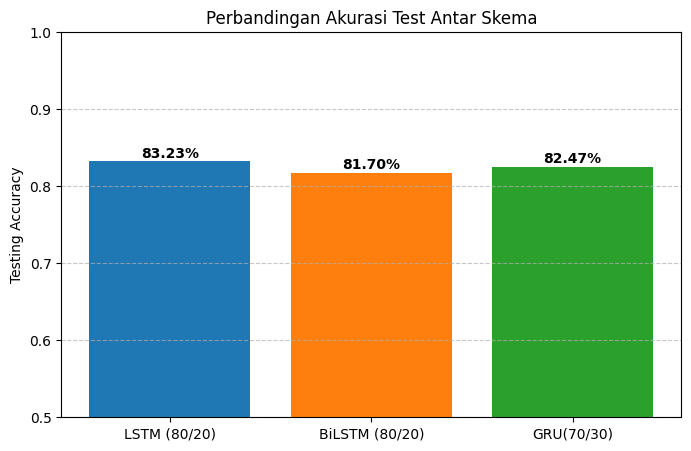

In [101]:
skema = ['LSTM (80/20)', 'BiLSTM (80/20)', 'GRU(70/30)']
test_accs = [te_acc1, te_acc2, te_acc3]

plt.figure(figsize=(8,5))
bars = plt.bar(skema, test_accs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0.5, 1.0)
plt.ylabel('Testing Accuracy')
plt.title('Perbandingan Akurasi Test Antar Skema')
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{acc:.2%}', ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()